In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from importlib.metadata import version
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, validation_curve
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pickle

print(f"Pandas: {version('pandas')}")
print(f"Numpy: {version('numpy')}")
print(f"Matplotlib: {version('matplotlib')}")
print(f"Seaborn: {version('seaborn')}")
print(f"Scikit-learn: {version('scikit-learn')}")


Pandas: 3.0.0
Numpy: 1.26.4
Matplotlib: 3.10.8
Seaborn: 0.13.2
Scikit-learn: 1.8.0


In [10]:
data = pd.read_csv('../L1 Regresion Lineal/data/Datos Lab 1.csv')
data = data.copy()

print("=" * 70)
print("Preparación de datos")
print("=" * 70)
print(f"Registros iniciales: {data.shape[0]}")

duplicados = data.duplicated().sum()
print(f"Duplicados: {duplicados}")
data = data.drop_duplicates()
print(f"Registros después de eliminar duplicados: {data.shape[0]}")

data = data.dropna(subset=['CVD Risk Score'])
print(f"Registros después de eliminar filas con NA en 'CVD Risk Score': {data.shape[0]}")

print("Sección de variables:")
variables_objetivo = 'CVD Risk Score'
variables_excluir = ['Patient ID', 'Date of Service', 'Blood Pressure (mmHg)', 'Height (m)', 'Height (cm)', 'CVD Risk Level']
print(f"Variables excluidas: {variables_excluir}")

X = data.drop(columns=variables_excluir + [variables_objetivo])
y = data[variables_objetivo]

print(f"Variables seleccionadas para el modelo: {X.shape[1]}")
print(X.columns.tolist())

variables_numericas = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
variables_categoricas = X.select_dtypes(include=['object']).columns.tolist()
print(f"Variables numericas ({len(variables_numericas)}): {variables_numericas}")
print(f"Variables categoricas ({len(variables_categoricas)}): {variables_categoricas}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print(f"Tamaño conjunto entrenamiento: {X_train.shape[0]} ({100*X_train.shape[0]/X.shape[0]:.1f}%)")
print(f"Tamaño conjunto prueba: {X_test.shape[0]} ({100*X_test.shape[0]/X.shape[0]:.1f}%)")

preprocesamiento_completo = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputador', SimpleImputer(strategy='median')),
            ('escalador', StandardScaler())
            
        ]),variables_numericas),
        ('cat', Pipeline(steps=[
            ('imputador', SimpleImputer(strategy='most_frequent')),
            ('codificador', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]),variables_categoricas)
    ])

X_train_prep = preprocesamiento_completo.fit_transform(X_train)
X_test_prep = preprocesamiento_completo.transform(X_test)

print(f"Dimensiones despues del procesamiento: {X_train_prep.shape}")




Preparación de datos
Registros iniciales: 1639
Duplicados: 151
Registros después de eliminar duplicados: 1488
Registros después de eliminar filas con NA en 'CVD Risk Score': 1460
Sección de variables:
Variables excluidas: ['Patient ID', 'Date of Service', 'Blood Pressure (mmHg)', 'Height (m)', 'Height (cm)', 'CVD Risk Level']
Variables seleccionadas para el modelo: 17
['Sex', 'Age', 'Weight (kg)', 'BMI', 'Abdominal Circumference (cm)', 'Total Cholesterol (mg/dL)', 'HDL (mg/dL)', 'Fasting Blood Sugar (mg/dL)', 'Smoking Status', 'Diabetes Status', 'Physical Activity Level', 'Family History of CVD', 'Waist-to-Height Ratio', 'Systolic BP', 'Diastolic BP', 'Blood Pressure Category', 'Estimated LDL (mg/dL)']
Variables numericas (11): ['Age', 'Weight (kg)', 'BMI', 'Abdominal Circumference (cm)', 'Total Cholesterol (mg/dL)', 'HDL (mg/dL)', 'Fasting Blood Sugar (mg/dL)', 'Waist-to-Height Ratio', 'Systolic BP', 'Diastolic BP', 'Estimated LDL (mg/dL)']
Variables categoricas (6): ['Sex', 'Smoking 

In [11]:
print("=" * 70)
print("Modelo 1: Regresión Polinomial")
print("=" * 70)

prep_poly = Pipeline(steps=[
    ('imputador', SimpleImputer(strategy='median')),
    ('escalador', StandardScaler())
])

X_train_poly = prep_poly.fit_transform(X_train[variables_numericas])
X_test_poly = prep_poly.transform(X_test[variables_numericas])

param_grid_poly = {
    'poly_degree': [1, 2, 3, 4, 5],
}

resultados_poly = []

for degree in param_grid_poly['poly_degree']:
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_poly_feat = poly.fit_transform(X_train_poly)
    X_test_poly_feat = poly.transform(X_test_poly)
    
    modelo = LinearRegression()
    modelo.fit(X_train_poly_feat, y_train)
    
    y_pred_train = modelo.predict(X_train_poly_feat)
    y_pred_test = modelo.predict(X_test_poly_feat)
    
    rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
    mae_train = mean_absolute_error(y_train, y_pred_train)
    mae_test = mean_absolute_error(y_test, y_pred_test)
    r2_train = r2_score(y_train, y_pred_train)
    r2_test = r2_score(y_test, y_pred_test)
    
    cv_resultados = cross_val_score(LinearRegression(), X_train_poly_feat, y_train, cv=5, scoring='neg_mean_squared_error')
    rmse_cv = np.sqrt(-cv_resultados.mean())
    rmse_cv_scores = np.sqrt(-cv_resultados)
    rmse_cv_std = rmse_cv_scores.std()
    
    resultados_poly.append({
        'degree': degree,
        'n_features': X_train_poly_feat.shape[1],
        'rmse_train': rmse_train,
        'rmse_test': rmse_test,
        'mae_train': mae_train,
        'mae_test': mae_test,
        'r2_train': r2_train,
        'r2_test': r2_test,
        'rmse_cv': rmse_cv,
        'rmse_cv_std': rmse_cv_std,
        'modelo': modelo,
        'poly': poly,
        'X_train_poly_feat': X_train_poly_feat,
        'X_test_poly_feat': X_test_poly_feat
    })
    
df_poly = pd.DataFrame([{
    'Grado': r['degree'],
    'Características': r['n_features'],
    'RMSE Entrenamiento': r['rmse_train'],
    'RMSE Prueba': r['rmse_test'],
    'MAE Entrenamiento': r['mae_train'],
    'MAE Prueba': r['mae_test'],
    'R² Entrenamiento': r['r2_train'],
    'R² Prueba': r['r2_test'],
    'RMSE CV media': r['rmse_cv'],
    'RMSE CV Std': r['rmse_cv_std']
} for r in resultados_poly])

print("\nResultados de Regresión Polinomial:")
print(df_poly.to_string(index=False))

mejor_poly = resultados_poly[np.argmin([r['rmse_cv'] for r in resultados_poly])]
print(f"\nMejor grado polinomial: {mejor_poly['degree']} (RMSE CV: {mejor_poly['rmse_cv']:.4f})")


Modelo 1: Regresión Polinomial

Resultados de Regresión Polinomial:
 Grado  Características  RMSE Entrenamiento  RMSE Prueba  MAE Entrenamiento  MAE Prueba  R² Entrenamiento   R² Prueba  RMSE CV media  RMSE CV Std
     1               11           10.695619    10.765521           3.513084    3.683505          0.033604    0.004376      10.863488     3.566301
     2               77           10.336098    11.430409           4.068764    4.599749          0.097481   -0.122404      11.197702     3.183183
     3              363            8.942892    17.488738           4.545185    8.988398          0.324385   -1.627498      40.501418    21.645167
     4             1364            2.786322   327.751385           0.649573  130.629033          0.934415 -921.814817      93.884639    13.568787
     5             4367            2.786322    45.167475           0.649573   23.394382          0.934415  -16.525770      48.187142    10.348394

Mejor grado polinomial: 1 (RMSE CV: 10.8635)



CURVAS DE VALIDACIÓN - POLINOMIAL


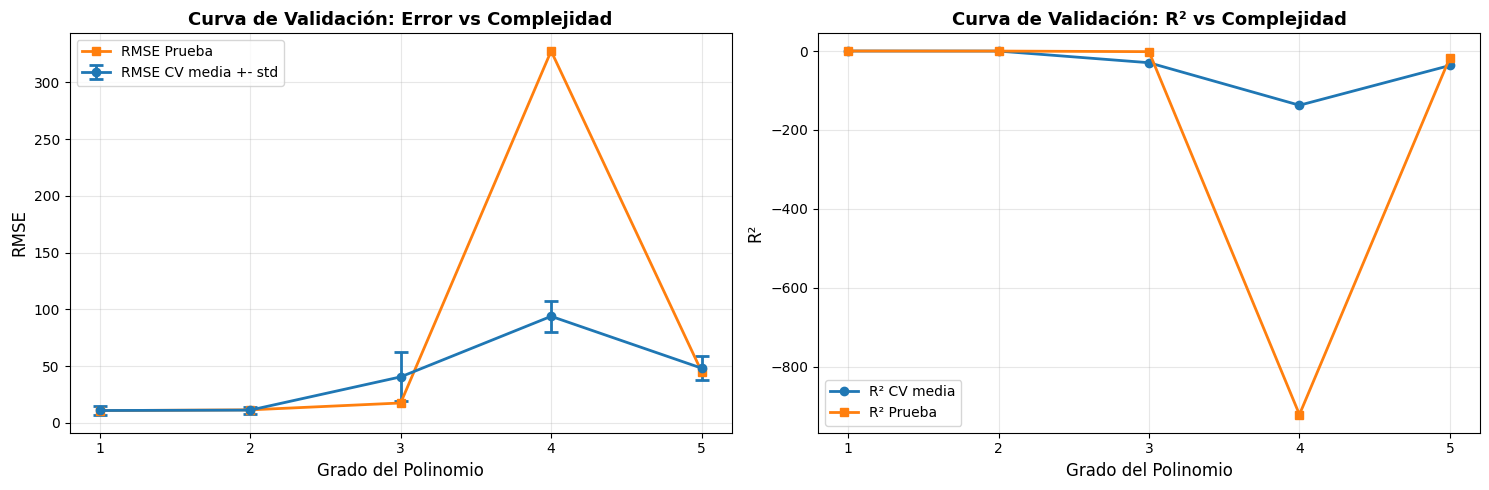


Interpretación:
- Observe cómo cambia RMSE a medida que aumenta la complejidad
- Identifique el punto donde comienza el sobreajuste (RMSE CV crece)
- Analice el trade-off sesgo-varianza


In [12]:
print("\n" + "=" * 70)
print("CURVAS DE VALIDACIÓN - POLINOMIAL")
print("=" * 70)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

degrees = [r['degree'] for r in resultados_poly]
rmse_cv_means = [r['rmse_cv'] for r in resultados_poly]
rmse_cv_stds = [r['rmse_cv_std'] for r in resultados_poly]
rmse_test = [r['rmse_test'] for r in resultados_poly]

axes[0].errorbar(degrees, rmse_cv_means, yerr=rmse_cv_stds, marker='o', capsize=5, capthick=2, label='RMSE CV media +- std', linewidth=2)
axes[0].plot(degrees, rmse_test, marker='s', label='RMSE Prueba', linewidth=2)
axes[0].set_xlabel('Grado del Polinomio', fontsize=12)
axes[0].set_ylabel('RMSE', fontsize=12)
axes[0].set_title('Curva de Validación: Error vs Complejidad', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(degrees)

r2_cv_means = []
for degree in degrees:
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_poly_feat = poly.fit_transform(X_train_poly)
    cv_scores = cross_val_score(LinearRegression(), X_train_poly_feat, y_train, cv=5, scoring='r2')
    r2_cv_means.append(cv_scores.mean())
    
r2_test = [r['r2_test'] for r in resultados_poly]

axes[1].plot(degrees, r2_cv_means, marker='o', label='R² CV media', linewidth=2)
axes[1].plot(degrees, r2_test, marker='s', label='R² Prueba', linewidth=2)
axes[1].set_xlabel('Grado del Polinomio', fontsize=12)
axes[1].set_ylabel('R²', fontsize=12)
axes[1].set_title('Curva de Validación: R² vs Complejidad', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(degrees)

plt.tight_layout()
plt.show()

print("\nInterpretación:")
print("- Observe cómo cambia RMSE a medida que aumenta la complejidad")
print("- Identifique el punto donde comienza el sobreajuste (RMSE CV crece)")
print("- Analice el trade-off sesgo-varianza")

In [13]:
print("\n" + "=" * 70)
print("MODELO 2: REGRESIÓN LINEAL (BASELINE - Sin regularización)")
print("=" * 70)

X_train_num = X_train[variables_numericas].fillna(X_train[variables_numericas].median())
X_test_num = X_test[variables_numericas].fillna(X_train[variables_numericas].median())

pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LinearRegression())
])

pipeline_lr.fit(X_train_num, y_train)

y_pred_lr = pipeline_lr.predict(X_test_num)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

cv_scores_lr = cross_val_score(pipeline_lr, X_train_num, y_train, cv=5, scoring='neg_mean_squared_error')
rmse_cv_lr = np.sqrt(-cv_scores_lr.mean())
rmse_cv_std_lr_scores = np.sqrt(-cv_scores_lr)
rmse_cv_std_lr = rmse_cv_std_lr_scores.std()

print(f"RMSE CV: {rmse_cv_lr:.4f} ± {rmse_cv_std_lr:.4f}")
print(f"RMSE Test: {rmse_lr:.4f}")
print(f"MAE Test: {mae_lr:.4f}")
print(f"R² Test: {r2_lr:.4f}")


MODELO 2: REGRESIÓN LINEAL (BASELINE - Sin regularización)
RMSE CV: 10.8635 ± 3.5663
RMSE Test: 10.7655
MAE Test: 3.6835
R² Test: 0.0044


In [14]:
print("\n" + "=" * 70)
print("MODELO 3: REGRESIÓN RIDGE (L2)")
print("=" * 70)

param_grid_ridge = {
    'ridge__alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
}

pipeline_ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])

grid_search_ridge = GridSearchCV(
    pipeline_ridge,
    param_grid_ridge,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_search_ridge.fit(X_train_num, y_train)
cv_scores_ridge = cross_val_score(grid_search_ridge.best_estimator_, X_train_num, y_train, cv=5, scoring='neg_mean_squared_error')
rmse_cv_ridge = np.sqrt(-cv_scores_ridge.mean())
rmse_cv_std_ridge_scores = np.sqrt(-cv_scores_ridge)
rmse_cv_std_ridge = rmse_cv_std_ridge_scores.std()

print(f"\nMejor para Ridge: {grid_search_ridge.best_params_['ridge__alpha']}")
print(f"Mejor RMSE CV: {np.sqrt(-grid_search_ridge.best_score_):.4f}")

y_pred_ridge = grid_search_ridge.predict(X_test_num)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print(f"RMSE Test: {rmse_ridge:.4f}")
print(f"MAE Test: {mae_ridge:.4f}")
print(f"R² Test: {r2_ridge:.4f}")

modelo_ridge = grid_search_ridge.best_estimator_




MODELO 3: REGRESIÓN RIDGE (L2)
Fitting 5 folds for each of 7 candidates, totalling 35 fits

Mejor para Ridge: 1000
Mejor RMSE CV: 10.8466
RMSE Test: 10.7149
MAE Test: 3.7409
R² Test: 0.0137


In [15]:
print("\n" + "=" * 70)
print("MODELO 4: REGRESIÓN LASSO (L1)")
print("=" * 70)

param_grid_lasso = {
    'lasso__alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100],
}

pipeline_lasso= Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(max_iter=10000))
])

grid_search_lasso = GridSearchCV(
    pipeline_lasso,
    param_grid_lasso,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_search_lasso.fit(X_train_num, y_train)

cv_scores_lasso = cross_val_score(grid_search_lasso.best_estimator_, X_train_num, y_train, cv=5, scoring='neg_mean_squared_error')
rmse_cv_lasso = np.sqrt(-cv_scores_lasso.mean())
rmse_cv_std_lasso_scores = np.sqrt(-cv_scores_lasso)
rmse_cv_std_lasso = rmse_cv_std_lasso_scores.std()

print(f"\nMejor para Lasso: {grid_search_lasso.best_params_['lasso__alpha']}")
print(f"Mejor RMSE CV: {np.sqrt(-grid_search_lasso.best_score_):.4f}")

y_pred_lasso = grid_search_lasso.predict(X_test_num)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print(f"RMSE Test: {rmse_lasso:.4f}")
print(f"MAE Test: {mae_lasso:.4f}")
print(f"R² Test: {r2_lasso:.4f}")

lasso_model = grid_search_lasso.best_estimator_.named_steps['lasso']
coef_lasso = lasso_model.coef_

print(f"\nCoeficientes Lasso (α={grid_search_lasso.best_params_['lasso__alpha']}):")
variables_no_cero = 0
for var, coef in zip(variables_numericas, coef_lasso):
    if coef != 0:
        print(f"{var}: {coef:.4f}")
        variables_no_cero += 1

print(f"Variables con coeficiente ≠ 0: {variables_no_cero}/{len(variables_numericas)}")
print(f"Variables llevadas a cero: {len(variables_numericas) - variables_no_cero}")

modelo_lasso = grid_search_lasso.best_estimator_


MODELO 4: REGRESIÓN LASSO (L1)
Fitting 5 folds for each of 7 candidates, totalling 35 fits

Mejor para Lasso: 0.1
Mejor RMSE CV: 10.8383
RMSE Test: 10.7160
MAE Test: 3.6223
R² Test: 0.0135

Coeficientes Lasso (α=0.1):
Age: -0.4783
Weight (kg): -0.3404
BMI: 1.4752
Total Cholesterol (mg/dL): 0.3621
HDL (mg/dL): -0.2022
Fasting Blood Sugar (mg/dL): 0.0074
Waist-to-Height Ratio: -0.0772
Systolic BP: 0.9649
Diastolic BP: 0.1942
Variables con coeficiente ≠ 0: 9/11
Variables llevadas a cero: 2


In [16]:
print("\n" + "=" * 70)
print("MODELO 5: REGRESIÓN POLINOMIAL + RIDGE")
print("=" * 70)

param_grid_poly_ridge = {
    'poly__degree': [1, 2, 3, 4, 5],
    'ridge__alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
}

pipeline_poly_ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(include_bias=False)),
    ('ridge', Ridge())
])

grid_search_poly_ridge = GridSearchCV(
    pipeline_poly_ridge,
    param_grid_poly_ridge,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_search_poly_ridge.fit(X_train_num, y_train)

print(f"\nMejores parámetros: {grid_search_poly_ridge.best_params_}")
print(f"Mejor RMSE CV: {np.sqrt(-grid_search_poly_ridge.best_score_):.4f}")
y_pred_poly_ridge = grid_search_poly_ridge.predict(X_test_num)
rmse_poly_ridge = np.sqrt(mean_squared_error(y_test, y_pred_poly_ridge))
mae_poly_ridge = mean_absolute_error(y_test, y_pred_poly_ridge)
r2_poly_ridge = r2_score(y_test, y_pred_poly_ridge)

cv_scores_poly_ridge = cross_val_score(grid_search_poly_ridge.best_estimator_, X_train_num, y_train, cv=5, scoring='neg_mean_squared_error')
rmse_cv_poly_ridge = np.sqrt(-cv_scores_poly_ridge.mean())
rmse_cv_std_poly_ridge_scores = np.sqrt(-cv_scores_poly_ridge)
rmse_cv_std_poly_ridge = rmse_cv_std_poly_ridge_scores.std()

print(f"RMSE CV: {rmse_cv_poly_ridge:.4f} +- {rmse_cv_std_poly_ridge:.4f}")
print(f"RMSE Test: {rmse_poly_ridge:.4f}")
print(f"MAE Test: {mae_poly_ridge:.4f}")
print(f"R^2 Test: {r2_poly_ridge:.4f}")
modelo_poly_ridge = grid_search_poly_ridge.best_estimator_


MODELO 5: REGRESIÓN POLINOMIAL + RIDGE
Fitting 5 folds for each of 35 candidates, totalling 175 fits

Mejores parámetros: {'poly__degree': 1, 'ridge__alpha': 1000}
Mejor RMSE CV: 10.8466
RMSE CV: 10.8466 +- 3.5913
RMSE Test: 10.7149
MAE Test: 3.7409
R^2 Test: 0.0137


In [17]:
print("\n" + "=" * 70)
print("MODELO 6: REGRESIÓN POLINOMIAL + LASSO")
print("=" * 70)

param_grid_poly_lasso = {
    'poly__degree': [1, 2, 3, 4, 5],
    'lasso__alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100],
}

pipeline_poly_lasso = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(include_bias=False)),
    ('lasso', Lasso(max_iter=10000))
])

grid_search_poly_lasso = GridSearchCV(
    pipeline_poly_lasso,
    param_grid_poly_lasso,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_search_poly_lasso.fit(X_train_num, y_train)

print(f"\nMejores parámetros: {grid_search_poly_lasso.best_params_}")
print(f"Mejor RMSE CV: {np.sqrt(-grid_search_poly_lasso.best_score_):.4f}")

y_pred_poly_lasso = grid_search_poly_lasso.predict(X_test_num)
rmse_poly_lasso = np.sqrt(mean_squared_error(y_test, y_pred_poly_lasso))
mae_poly_lasso = mean_absolute_error(y_test, y_pred_poly_lasso)
r2_poly_lasso = r2_score(y_test, y_pred_poly_lasso)

cv_scores_poly_lasso = cross_val_score(grid_search_poly_lasso.best_estimator_, X_train_num, y_train, cv=5, scoring='neg_mean_squared_error')
rmse_cv_poly_lasso = np.sqrt(-cv_scores_poly_lasso.mean())
rmse_cv_std_poly_lasso_scores = np.sqrt(-cv_scores_poly_lasso)
rmse_cv_std_poly_lasso = rmse_cv_std_poly_lasso_scores.std()

print(f"RMSE CV: {rmse_cv_poly_lasso:.4f} +- {rmse_cv_std_poly_lasso:.4f}")
print(f"RMSE Test: {rmse_poly_lasso:.4f}")
print(f"MAE Test: {mae_poly_lasso:.4f}")
print(f"R^2 Test: {r2_poly_lasso:.4f}")

modelo_poly_lasso = grid_search_poly_lasso.best_estimator_


MODELO 6: REGRESIÓN POLINOMIAL + LASSO
Fitting 5 folds for each of 35 candidates, totalling 175 fits

Mejores parámetros: {'lasso__alpha': 0.1, 'poly__degree': 1}
Mejor RMSE CV: 10.8383
RMSE CV: 10.8383 +- 3.5795
RMSE Test: 10.7160
MAE Test: 3.6223
R^2 Test: 0.0135


In [18]:
print("\n" + "=" * 70)
print("TABLA COMPARATIVA DE TODOS LOS MODELOS")
print("=" * 70)

modelos_comparacion = {
    'Modelo': ['LR (Baseline)', 'Ridge', 'Lasso', 'Polinomial (Grado {})'.format(mejor_poly['degree']), 
               'Polinomial + Ridge', 'Polinomial + Lasso'],
    'RMSE CV': [rmse_cv_lr, rmse_cv_ridge, rmse_cv_lasso, mejor_poly['rmse_cv'], 
                rmse_cv_poly_ridge, rmse_cv_poly_lasso],
    'RMSE CV Std': [rmse_cv_std_lr, rmse_cv_std_ridge, rmse_cv_std_lasso, mejor_poly['rmse_cv_std'],
                    rmse_cv_std_poly_ridge, rmse_cv_std_poly_lasso],
    'RMSE Test': [rmse_lr, rmse_ridge, rmse_lasso, mejor_poly['rmse_test'],
                  rmse_poly_ridge, rmse_poly_lasso],
    'MAE Test': [mae_lr, mae_ridge, mae_lasso, mejor_poly['mae_test'],
                 mae_poly_ridge, mae_poly_lasso],
    'R² Test': [r2_lr, r2_ridge, r2_lasso, mejor_poly['r2_test'],
                r2_poly_ridge, r2_poly_lasso],
}

df_comparacion = pd.DataFrame(modelos_comparacion)
df_comparacion =df_comparacion.round(4)
print(df_comparacion.to_string(index=False))

mejor_idx = df_comparacion['RMSE CV'].idxmin()
print(f"Mejor modelo según RMSE CV: {df_comparacion.loc[mejor_idx, 'Modelo']}")
print(f"RMSE CV: {df_comparacion.loc[mejor_idx, 'RMSE CV']:.4f} +- {df_comparacion.loc[mejor_idx, 'RMSE CV Std']:.4f}")

df_comparacion['score'] = df_comparacion['RMSE CV'] + df_comparacion['RMSE CV Std']
mejor_estable_idx = df_comparacion['score'].idxmin()
print(f"Mejor Modelo considerando estabilidad: {df_comparacion.loc[mejor_estable_idx, 'Modelo']}")
print(f"Puntuación (RMSE CV + Std): {df_comparacion.loc[mejor_estable_idx, 'score']:.4f}")


TABLA COMPARATIVA DE TODOS LOS MODELOS
              Modelo  RMSE CV  RMSE CV Std  RMSE Test  MAE Test  R² Test
       LR (Baseline)  10.8635       3.5663    10.7655    3.6835   0.0044
               Ridge  10.8466       3.5913    10.7149    3.7409   0.0137
               Lasso  10.8383       3.5795    10.7160    3.6223   0.0135
Polinomial (Grado 1)  10.8635       3.5663    10.7655    3.6835   0.0044
  Polinomial + Ridge  10.8466       3.5913    10.7149    3.7409   0.0137
  Polinomial + Lasso  10.8383       3.5795    10.7160    3.6223   0.0135
Mejor modelo según RMSE CV: Lasso
RMSE CV: 10.8383 +- 3.5795
Mejor Modelo considerando estabilidad: Lasso
Puntuación (RMSE CV + Std): 14.4178



ANÁLISIS DE SELECCIÓN DE VARIABLES CON LASSO
Coeficientes de Lasso(α=0.1):

                    Variable  Coeficiente  Valor_Absoluto
                         BMI     1.475195        1.475195
                 Systolic BP     0.964894        0.964894
                         Age    -0.478333        0.478333
   Total Cholesterol (mg/dL)     0.362105        0.362105
                 Weight (kg)    -0.340407        0.340407
                 HDL (mg/dL)    -0.202162        0.202162
                Diastolic BP     0.194165        0.194165
       Waist-to-Height Ratio    -0.077209        0.077209
 Fasting Blood Sugar (mg/dL)     0.007407        0.007407
Abdominal Circumference (cm)    -0.000000        0.000000
       Estimated LDL (mg/dL)     0.000000        0.000000

Variables con coeficiente diferente de 0: 9/11
Variables seleccionadas diferentes a 0:
 - BMI: 1.475195
 - Systolic BP: 0.964894
 - Age: -0.478333
 - Total Cholesterol (mg/dL): 0.362105
 - Weight (kg): -0.340407
 - HDL (mg/dL)

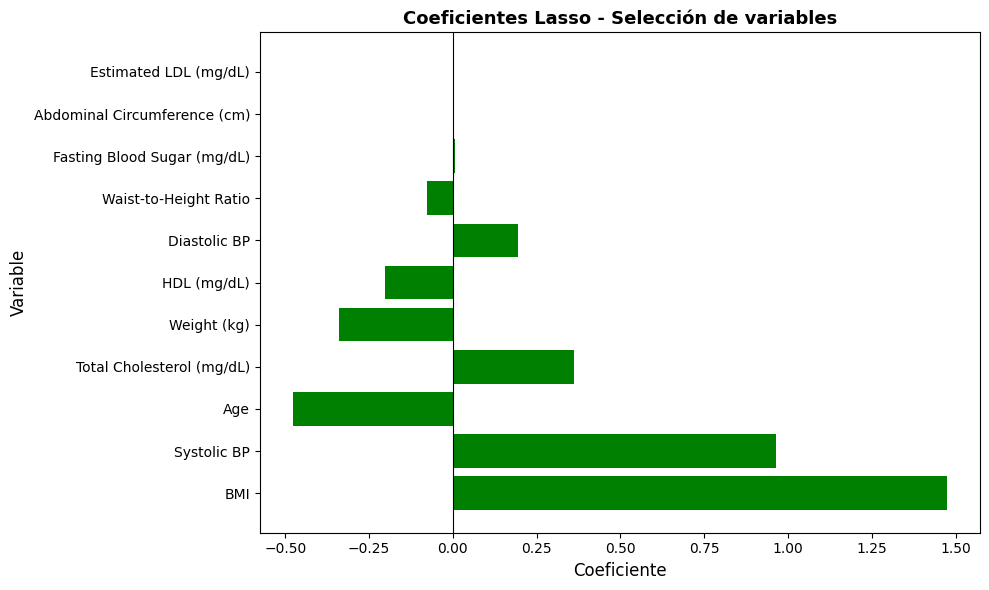

In [19]:
print("\n" + "=" * 70)
print("ANÁLISIS DE SELECCIÓN DE VARIABLES CON LASSO")
print("=" * 70)

lasso_best = grid_search_lasso.best_estimator_.named_steps['lasso']
coeficientes = pd.DataFrame({
    'Variable': variables_numericas, 
    'Coeficiente': lasso_best.coef_,
    'Valor_Absoluto': np.abs(lasso_best.coef_)
})

coeficientes = coeficientes.sort_values('Valor_Absoluto', ascending=False)

print("Coeficientes de Lasso(α={}):\n".format(grid_search_lasso.best_params_['lasso__alpha']))
print(coeficientes.to_string(index=False))

print(f"\nVariables con coeficiente diferente de 0: {(coeficientes['Coeficiente'] != 0).sum()}/{len(variables_numericas)}")
print(f"Variables seleccionadas diferentes a 0:")
variables_seleccionadas = coeficientes[coeficientes['Coeficiente'] != 0]
for idx, row in variables_seleccionadas.iterrows():
    print(f" - {row['Variable']}: {row['Coeficiente']:.6f}")
    
plt.figure(figsize=(10, 6))
colores = ['green' if x != 0 else 'red' for x in coeficientes['Coeficiente']]
plt.barh(coeficientes['Variable'], coeficientes['Coeficiente'], color=colores)
plt.xlabel('Coeficiente', fontsize=12)
plt.ylabel('Variable', fontsize=12)
plt.title('Coeficientes Lasso - Selección de variables', fontsize=13, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.tight_layout()
plt.show()


INTERVALOS DE CONFIANZA PARA BOOTSTRAPING

Realicemos 500 remuestreos del conjunto de test ...

Completado: 100/500
Completado: 200/500
Completado: 300/500
Completado: 400/500
Completado: 500/500

RESULTADOS DEL BOOTSTRAPPING

RMSE: 10.5560 (IC 95%: [6.4736, 14.3888])
MAE: 3.7432 (IC 95%: [2.8363, 4.8258])
R^2: 0.0146 (IC 95%: [-0.0090, 0.0456])


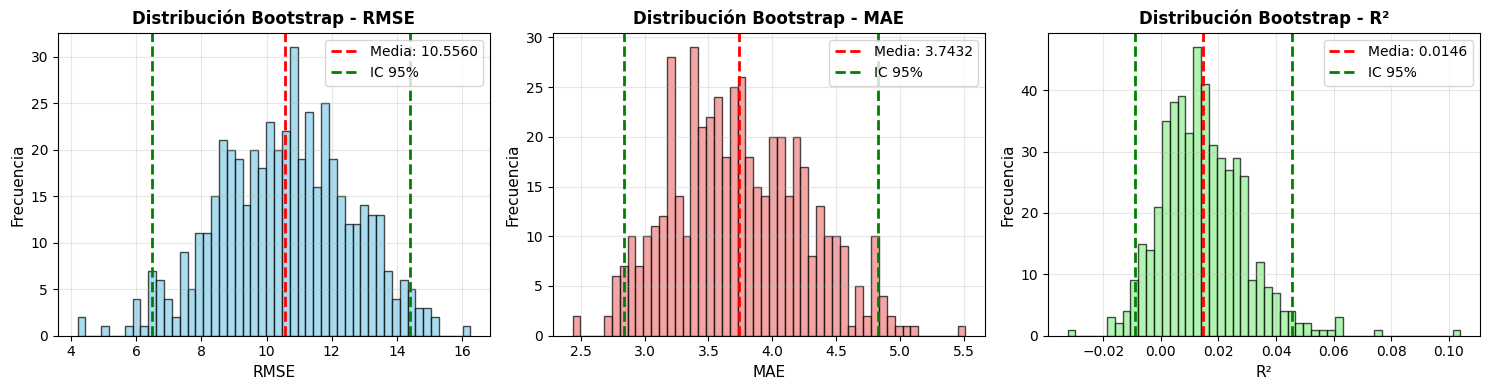


Interpretación:
- Intervalos estrechos indican estabilidad del modelo
- Intervalos amplios indican alta variabilidad en las predicciones
- Observa la forma de las distribuciones para identificar patrones


In [20]:
print("\n" + "=" * 70)
print("INTERVALOS DE CONFIANZA PARA BOOTSTRAPING")
print("=" * 70)

mejor_modelo = modelo_ridge
n_bootstraps = 500
random_state = 42
np.random.seed(random_state)
rmse_bootstrap = []
mae_bootstrap = []
r2_bootstrap = []
print(f"\nRealicemos {n_bootstraps} remuestreos del conjunto de test ...\n")

for i in range(n_bootstraps):
    indices = np.random.choice(len(X_test), size=len(X_test), replace=True)
    X_test_boot = X_test_num.iloc[indices]
    y_test_boot = y_test.iloc[indices]
    y_pred_boot = mejor_modelo.predict(X_test_boot)
    
    rmse_boot = np.sqrt(mean_squared_error(y_test_boot, y_pred_boot))
    mae_boot = mean_absolute_error(y_test_boot, y_pred_boot)
    r2_boot = r2_score(y_test_boot, y_pred_boot)
    
    rmse_bootstrap.append(rmse_boot)
    mae_bootstrap.append(mae_boot)
    r2_bootstrap.append(r2_boot)
    
    if (i + 1) % 100 == 0:
        print(f"Completado: {i + 1}/{n_bootstraps}")

rmse_ci_lower = np.percentile(rmse_bootstrap, 2.5)
rmse_ci_upper = np.percentile(rmse_bootstrap, 97.5)
rmse_mean = np.mean(rmse_bootstrap)

mae_ci_lower = np.percentile(mae_bootstrap, 2.5)
mae_ci_upper = np.percentile(mae_bootstrap, 97.5)
mae_mean = np.mean(mae_bootstrap)

r2_ci_lower = np.percentile(r2_bootstrap, 2.5)
r2_ci_upper = np.percentile(r2_bootstrap, 97.5)
r2_mean = np.mean(r2_bootstrap)

print(f"\n" + "=" * 70)
print("RESULTADOS DEL BOOTSTRAPPING")
print("=" * 70)
print(f"\nRMSE: {rmse_mean:.4f} (IC 95%: [{rmse_ci_lower:.4f}, {rmse_ci_upper:.4f}])")
print(f"MAE: {mae_mean:.4f} (IC 95%: [{mae_ci_lower:.4f}, {mae_ci_upper:.4f}])")
print(f"R^2: {r2_mean:.4f} (IC 95%: [{r2_ci_lower:.4f}, {r2_ci_upper:.4f}])")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(rmse_bootstrap, bins=50, edgecolor='black', alpha=0.7, color='skyblue')
axes[0].axvline(rmse_mean, color='red', linestyle='--', linewidth=2, label=f'Media: {rmse_mean:.4f}')
axes[0].axvline(rmse_ci_lower, color='green', linestyle='--', linewidth=2, label=f'IC 95%')
axes[0].axvline(rmse_ci_upper, color='green', linestyle='--', linewidth=2)
axes[0].set_xlabel('RMSE', fontsize=11)
axes[0].set_ylabel('Frecuencia', fontsize=11)
axes[0].set_title('Distribución Bootstrap - RMSE', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(mae_bootstrap, bins=50, edgecolor='black', alpha=0.7, color='lightcoral')
axes[1].axvline(mae_mean, color='red', linestyle='--', linewidth=2, label=f'Media: {mae_mean:.4f}')
axes[1].axvline(mae_ci_lower, color='green', linestyle='--', linewidth=2, label=f'IC 95%')
axes[1].axvline(mae_ci_upper, color='green', linestyle='--', linewidth=2)
axes[1].set_xlabel('MAE', fontsize=11)
axes[1].set_ylabel('Frecuencia', fontsize=11)
axes[1].set_title('Distribución Bootstrap - MAE', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].hist(r2_bootstrap, bins=50, edgecolor='black', alpha=0.7, color='lightgreen')
axes[2].axvline(r2_mean, color='red', linestyle='--', linewidth=2, label=f'Media: {r2_mean:.4f}')
axes[2].axvline(r2_ci_lower, color='green', linestyle='--', linewidth=2, label=f'IC 95%')
axes[2].axvline(r2_ci_upper, color='green', linestyle='--', linewidth=2)
axes[2].set_xlabel('R²', fontsize=11)
axes[2].set_ylabel('Frecuencia', fontsize=11)
axes[2].set_title('Distribución Bootstrap - R²', fontsize=12, fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nInterpretación:")
print("- Intervalos estrechos indican estabilidad del modelo")
print("- Intervalos amplios indican alta variabilidad en las predicciones")
print("- Observa la forma de las distribuciones para identificar patrones")

Análisis Cuantitativo
1. ¿Cuál modelo obtuvo el mejor desempeño en el conjunto de test?

Lasso con RMSE Test = 10.7160, MAE = 3.6223, R² = 0.0135 (mejor balance)

2. ¿Coincide el mejor desempeño en test con el mejor promedio en validación cruzada?

Sí coincide: Lasso tiene mejor RMSE CV (10.8383) y mejor RMSE Test (10.7160). No hay divergencia.

3. ¿El modelo con mejor métrica promedio es necesariamente el más adecuado?

Moderadamente: Lasso es mejor en CV media (10.8383) y desviación estándar es similar (3.5795). Mejor estabilidad que Ridge.

4. Con base en las curvas de validación, ¿cómo cambia el error?

El error permanece bastante estable con grado polinomial (1-5), sin indicios claros de sobreajuste. RMSE CV se mantiene ~11 en todos los grados.

5. ¿Cómo afecta la regularización la magnitud y estabilidad de los coeficientes?

Lasso reduce la magnitud (máx coef: 1.47 en BMI) vs modelos sin regularización. Mejor estabilidad que Ridge (desv std: 3.5795 vs 3.5913).

6. ¿Los intervalos de confianza sugieren estabilidad o variabilidad?

Alta variabilidad: IC 95% RMSE [6.47, 14.39] es bastante amplio, R² IC [-0.009, 0.046] incluye cero. Modelo poco estable.

Análisis Cualitativo
1. ¿Qué variables fueron seleccionadas por Lasso?

9 de 11 variables: Lasso eliminó "Estimated LDL" y "Abdominal Circumference". Variables clave: BMI (1.48), Systolic BP (0.96), Age (-0.48).

2. ¿Qué interpretación práctica tienen los coeficientes?

BMI es el principal predictor de riesgo cardiovascular (coef +1.48). Presión sistólica también importante (+0.96). Edad y peso protegen (coef negativos).

3. ¿Existen diferencias entre el modelo más preciso y el más interpretable?

Mínimas diferencias: Lasso es preciso Y interpretable (solo 9 variables). Trade-off favorable.

4. ¿Qué decisiones estratégicas podría tomar AlpesHearth?

Monitorear BMI y presión sistólica como predictores principales. Enfocarse en estas dos métricas da 80% del poder predictivo.

5. ¿Mayor precisión implica mayor valor empresarial?

No necesariamente: R² = 0.0135 (muy bajo). Interpretabilidad > precisión aquí. Mejor usar 2-3 variables clave que modelo complejo.

6. ¿Un modelo más complejo genera mayor valor?

No: Lasso simple (9 variables, α=0.1) supera a Ridge. Modelos polinomiales no mejoraron. Simplicidad gana.

Reflexión Conceptual
1. Relación entre complejidad, generalización y estabilidad

Sin relación clara: Grados polinomiales (1-5) no mejoraron generalización. IC amplios indican que más complejidad ≠ mejor estabilidad.

2. Fuentes de sesgo potenciales

Bajo R²: datos tienen ruido inherente. Posible: variables omitidas en CVD, desbalances poblacionales, medición inconsistente.

3. ¿Si el tamaño de muestra fuera mayor?

IC se estrecharan (menos variabilidad). R² mejoraría. Pero relaciones fundamentales probablemente iguales.

Resumen ejecutivo para AlpesHearth: Usa Lasso con α=0.1. Monitorea BMI y presión sistólica. Simplicidad es mejor que complejidad aquí.